# 1. Introducción

## Explicación

El fraude financiero es uno de los principales problemas dentro del sector bancario y fintech, ya que puede generar pérdidas económicas importantes y afectar la seguridad de los clientes.

En este proyecto voy a trabajar con un dataset de transacciones realizadas con tarjetas de crédito, con el objetivo de analizar y preparar los datos para futuros modelos de Machine Learning orientados a la detección de fraude financiero.

# 2. Selección del Dataset

Elegí el dataset “Credit Card Fraud Detection” disponible en Kaggle porque me interesa el área de Risk Analytics y prevención de fraude financiero.

El dataset contiene transacciones realizadas con tarjetas de crédito y cada operación se encuentra clasificada como:
- 0 → transacción normal
- 1 → transacción fraudulenta

Por motivos de privacidad y confidencialidad financiera, la mayoría de las variables del dataset fueron anonimizadas mediante técnicas de transformación PCA (Principal Component Analysis). Por este motivo, las variables aparecen representadas como V1, V2, V3, etc. Únicamente las variables Time y Amount permanecen en formato original.

Además, el dataset permite aplicar muchas de las etapas vistas en clase como:
- análisis exploratorio
- limpieza de datos
- detección de outliers
- transformaciones
- preparación para Machine Learning

> Corrección técnica: para evitar fuga de datos, el escalador no debe ajustarse antes de dividir el dataset. Primero se realiza el `train_test_split` y luego se ajusta el `StandardScaler` solo con `X_train`.

# 3. Importación de Librerías

Primero se importan las librerías que se utilizarán durante el análisis y preparación de los datos.

In [29]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

import os

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 4. Carga del Dataset

In [30]:
# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

csv_path = os.path.join(path, "creditcard.csv")

df = pd.read_csv(csv_path)

df.head()

Using Colab cache for faster access to the 'creditcardfraud' dataset.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# 5. Exploración Inicial del Dataset

Antes de comenzar con el análisis, es importante entender la estructura general del dataset.

In [31]:
df.shape

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Con esta exploración inicial se puede observar:
- cantidad de filas y columnas
- tipos de datos
- estadísticas generales
- comportamiento inicial de las variables

Esto ayuda a tener una idea general de la calidad y estructura de los datos.

# 6. Verificación de Valores Faltantes

Es importante revisar si existen valores faltantes, ya que podrían afectar futuros modelos de Machine Learning.

In [32]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


En este caso el dataset no presenta valores nulos, lo cual facilita bastante el proceso de limpieza y preparación de datos.

# 7. Verificación de Duplicados

In [33]:
df.duplicated().sum()

df = df.drop_duplicates()

Eliminar duplicados ayuda a evitar ruido o posibles sesgos durante el análisis y entrenamiento de modelos.

# 8. Distribución de la Variable Objetivo

La variable `Class` indica si una transacción es normal o fraudulenta.

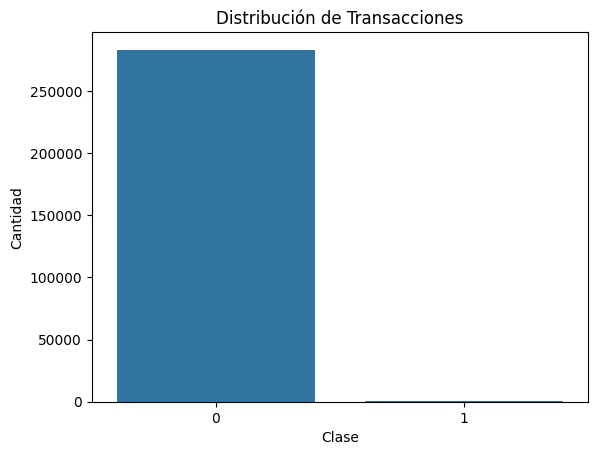

In [34]:
df["Class"].value_counts()

df["Class"].value_counts(normalize=True) * 100

sns.countplot(x="Class", data=df)

plt.title("Distribución de Transacciones")
plt.xlabel("Clase")
plt.ylabel("Cantidad")

plt.show()

Se observa un fuerte desbalance de clases, donde las transacciones fraudulentas representan una proporción muy pequeña del total.

Este comportamiento es muy común en problemas reales de detección de fraude financiero.

# 9. Distribución de Variables Numéricas

A continuación se analizarán algunas variables numéricas importantes del dataset.

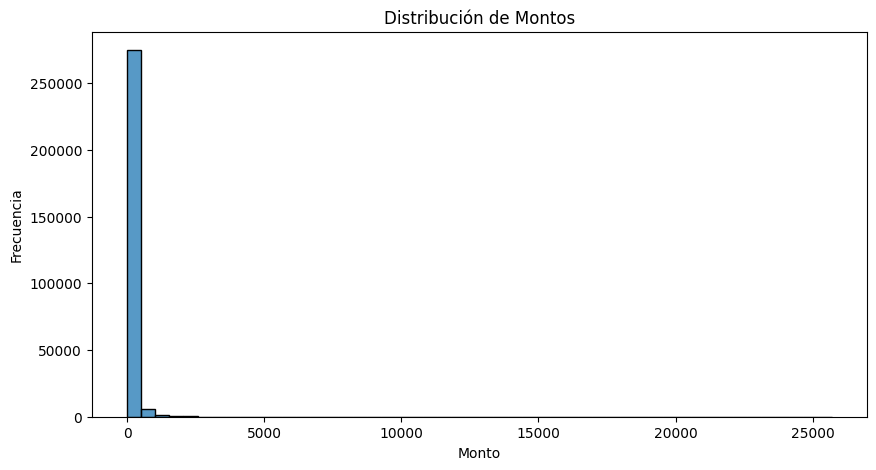

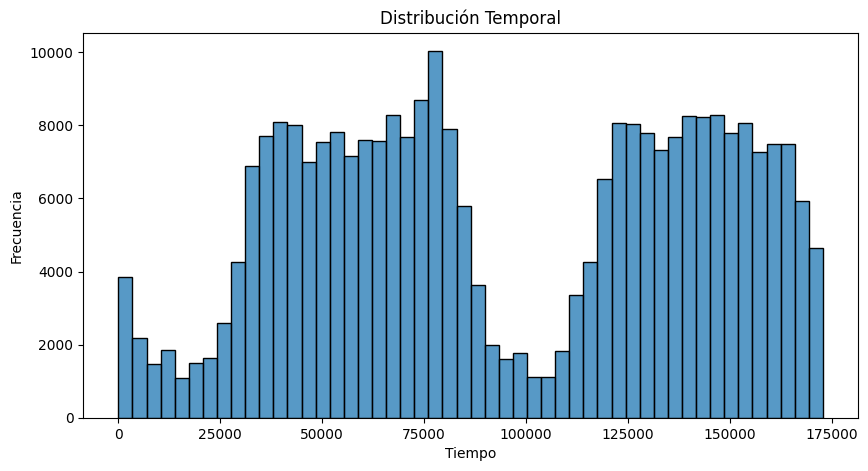

In [35]:
plt.figure(figsize=(10,5))

sns.histplot(df["Amount"], bins=50)

plt.title("Distribución de Montos")
plt.xlabel("Monto")
plt.ylabel("Frecuencia")

plt.show()

plt.figure(figsize=(10,5))

sns.histplot(df["Time"], bins=50)

plt.title("Distribución Temporal")
plt.xlabel("Tiempo")
plt.ylabel("Frecuencia")

plt.show()

## Interpretación de Resultados

La mayoría de las transacciones presentan montos relativamente bajos, aunque también existen operaciones con valores mucho más elevados.

Esto puede resultar importante para el análisis de posibles fraudes.

# 10. Detección de Outliers

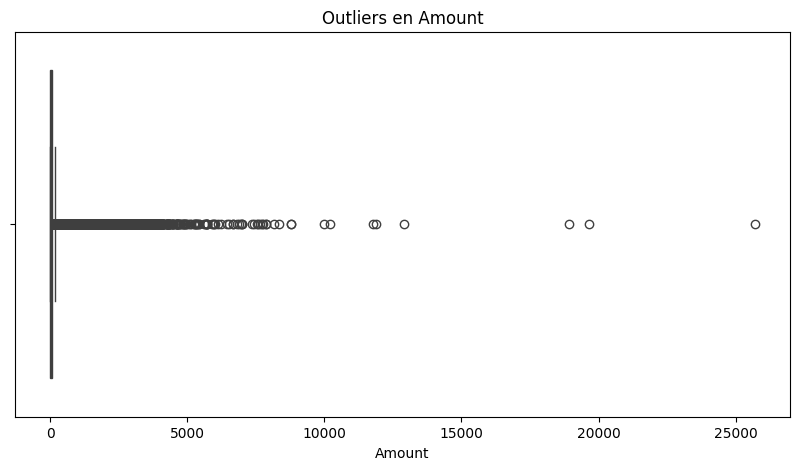

In [36]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df["Amount"])

plt.title("Outliers en Amount")

plt.show()

## Interpretación de Resultados

Se observan varios valores extremos dentro de la variable `Amount`.

En datasets financieros este tipo de comportamiento puede resultar relevante, ya que algunas operaciones fraudulentas suelen presentar montos inusuales.

# 11. Análisis de Correlaciones

El análisis de correlaciones permite identificar relaciones entre variables.

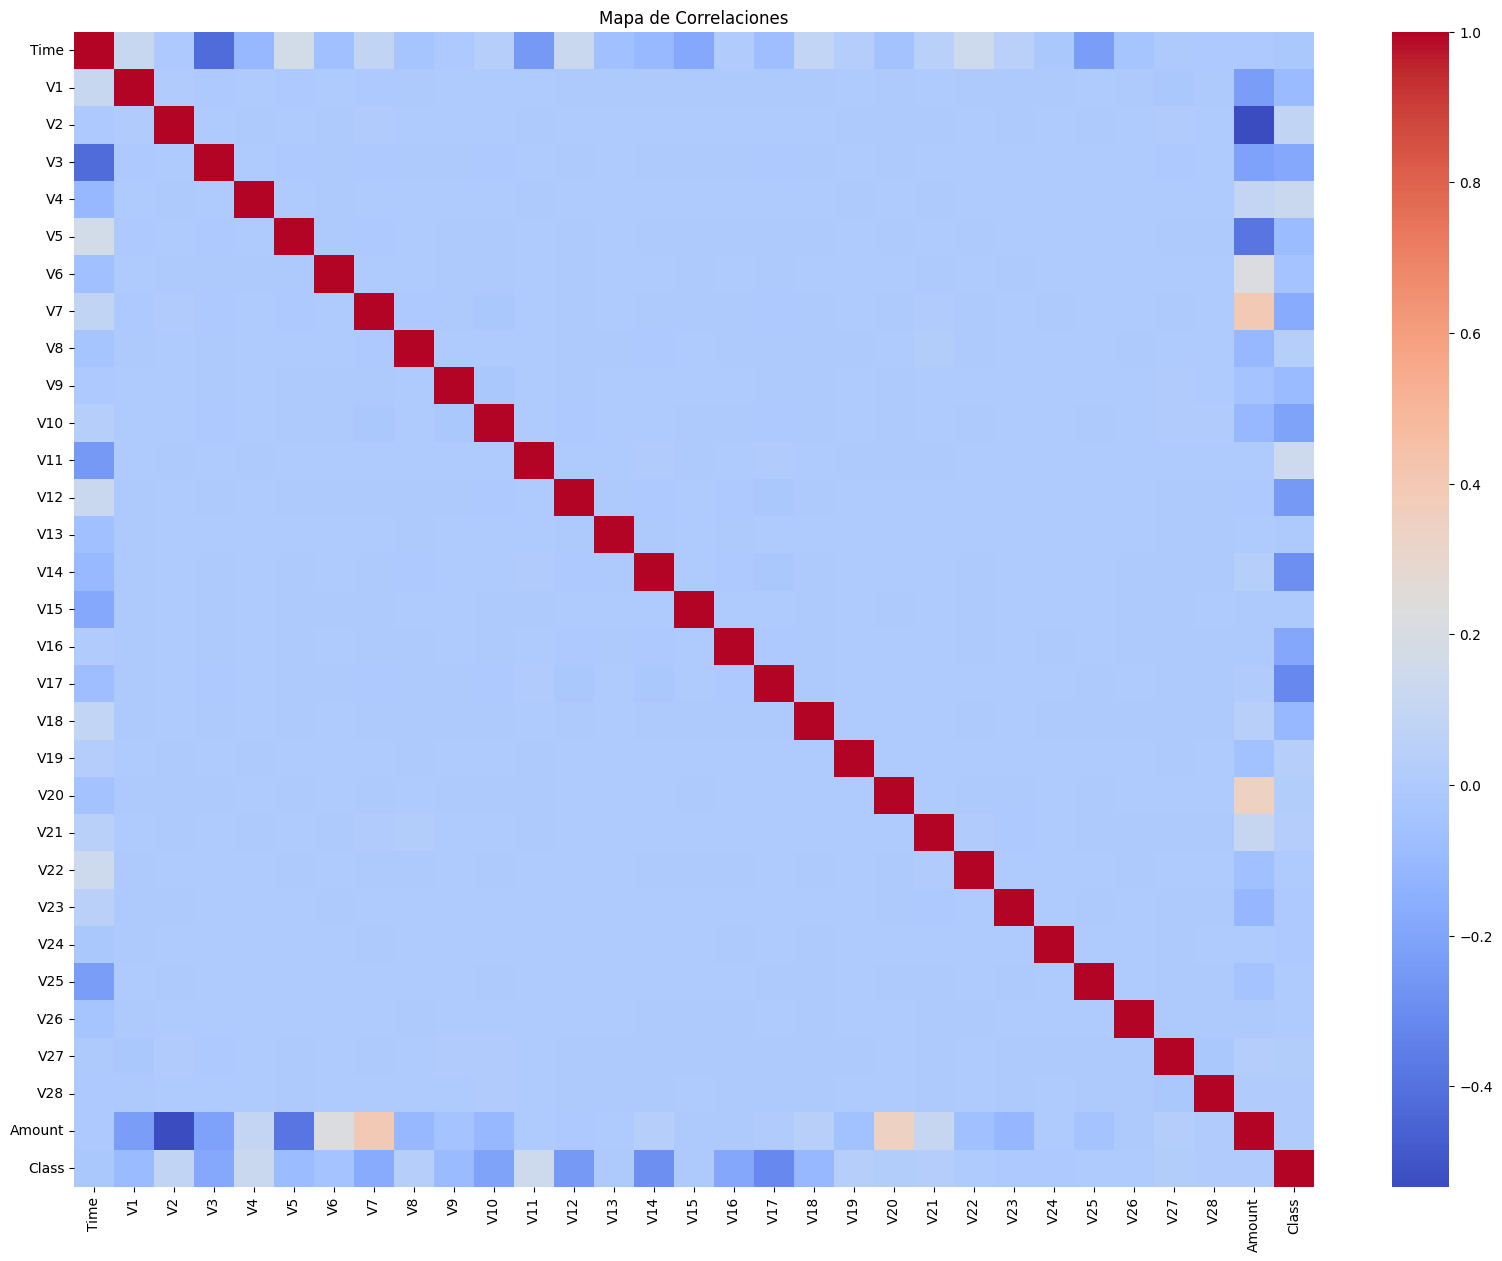

,Class
Class,1.000000
V11,0.149067
V4,0.129326
V2,0.084624
V19,0.033631
V8,0.033068
V21,0.026357
V27,0.021892
V20,0.021486
V28,0.009682


In [37]:
corr = df.corr()

plt.figure(figsize=(20,15))

sns.heatmap(corr, cmap="coolwarm")

plt.title("Mapa de Correlaciones")

plt.show()

corr["Class"].sort_values(ascending=False)

## Interpretación de Resultados

Algunas variables presentan una mayor relación con la variable objetivo (`Class`).

Esto puede resultar útil más adelante para seleccionar variables importantes durante el entrenamiento de modelos.

# 12. Selección de Variables

Ahora se separarán las variables predictoras de la variable objetivo.

In [38]:
X = df.drop("Class", axis=1)

y = df["Class"]

## Interpretación de Resultados

La variable `Class` será la variable objetivo que el modelo intentará predecir en futuras etapas.

# 13. División del Dataset

Por último, el dataset se dividirá entre entrenamiento y prueba.

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(226980, 30)
(56746, 30)
(226980,)
(56746,)


## Interpretación de Resultados

Se utilizará un 80% de los datos para entrenamiento y un 20% para prueba.

Esto permitirá evaluar más adelante el rendimiento de los modelos utilizando datos no vistos previamente.

## Verificación del balance luego del split

Como el dataset está muy desbalanceado, se verifica que la proporción de clases se mantenga parecida en entrenamiento y prueba gracias al uso de `stratify=y`.

In [40]:
print("Distribución en y_train:")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribución en y_test:")
print(y_test.value_counts(normalize=True) * 100)

Distribución en y_train:
Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64

Distribución en y_test:
Class
0    99.832587
1     0.167413
Name: proportion, dtype: float64


# 14. Escalado de Variables

> Corrección técnica: para evitar fuga de datos, el escalador no debe ajustarse antes de dividir el dataset. Primero se realiza el `train_test_split` y luego se ajusta el `StandardScaler` solo con `X_train`.

## Escalado posterior al Train/Test Split
La idea es:
- primero dividir el dataset en entrenamiento y prueba
- luego ajustar el `StandardScaler` solamente con `X_train`
- finalmente aplicar esa misma transformación sobre `X_test`

Esto evita que el conjunto de prueba aporte información durante la preparación de los datos.

In [41]:
scaler = StandardScaler()

# Se crean copias para evitar advertencias de pandas
X_train = X_train.copy()
X_test = X_test.copy()

# El scaler se ajusta SOLO con los datos de entrenamiento
X_train[["Amount", "Time"]] = scaler.fit_transform(X_train[["Amount", "Time"]])

# Al conjunto de prueba solo se le aplica la transformación ya aprendida
X_test[["Amount", "Time"]] = scaler.transform(X_test[["Amount", "Time"]])

X_train.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
226238,1.045499,2.238954,-1.724499,-2.151484,-2.577803,0.993668,3.565492,-1.785957,0.860122,-1.264003,...,-0.323810,-0.149574,-0.049333,0.278442,0.684735,-0.219028,-0.159167,0.037920,-0.049932,-0.229434
134253,-0.298690,-1.315062,1.630783,0.597001,-0.038359,-0.404580,-0.965712,0.212249,0.735381,-1.267926,...,-0.067580,-0.238898,-0.946773,0.323904,0.515632,-0.713000,-0.266503,-0.017794,0.051058,-0.331197
186465,0.678397,1.908801,0.021184,-2.087997,0.129310,1.161468,0.605244,-0.022371,0.180296,0.283819,...,-0.210474,0.293609,1.095842,-0.044874,-1.689517,0.106098,0.007758,0.045164,-0.053068,-0.298809
149493,-0.074929,1.811257,0.316556,0.316751,3.880231,0.048454,1.020163,-0.734868,0.233651,0.681423,...,-0.228032,0.138869,0.700422,0.174064,0.702997,-0.212523,-0.010018,-0.017740,-0.038006,-0.289247
18461,-1.376728,1.358817,-1.120881,0.550266,-1.547659,-1.194950,0.275448,-1.201843,0.212889,-2.094285,...,-0.361686,-0.340972,-0.636442,0.252758,-0.344160,-0.064282,-0.439622,0.062524,0.013095,-0.261985


### Interpretación

Con este cambio se evita la fuga de datos (*data leakage*), porque el escalador no utiliza información del conjunto de prueba para aprender la media y el desvío estándar.

Esto deja la preparación del dataset mejor planteada para una futura etapa de modelado.

## Interpretación de Resultados

El escalado ayuda a que las variables tengan magnitudes similares y evita que algunas tengan demasiada influencia sobre futuros modelos de Machine Learning.

> Corrección técnica: para evitar fuga de datos, el escalador no debe ajustarse antes de dividir el dataset. Primero se realiza el `train_test_split` y luego se ajusta el `StandardScaler` solo con `X_train`.

# 15. Conclusiones

Durante esta pre-entrega se realizó:
- exploración inicial del dataset
- limpieza de datos
- análisis exploratorio
- detección de outliers
- análisis de correlaciones
- transformaciones de variables
- división entre entrenamiento y prueba

Gracias a este proceso, el dataset quedó preparado para futuras etapas de Machine Learning orientadas a la detección de fraude financiero.

> Corrección técnica: para evitar fuga de datos, el escalador no debe ajustarse antes de dividir el dataset. Primero se realiza el `train_test_split` y luego se ajusta el `StandardScaler` solo con `X_train`.